<a href="https://colab.research.google.com/github/lyntos/Python_MS_Wilmu_02/blob/main/7_Exercises_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 Exercises
## Natural Language Processing (NLP)



Chapter 12 – Natural Language Processing (NLP)



## 12.001 Import Statements

In [ ]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.tokenize import word_tokenize
import re

In [ ]:
nltk.download("gutenberg", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download('punkt_tab', quiet=True)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
!python -m textblob.download_corpora
%pip install nltk

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


## 12.1 (Web Scraping with the Requests and Beautiful Soup Libraries)
Web pages are excellent sources of text to use in NLP tasks. In the following IPython session, you’ll use the  library to download the www.python.org home page’s content. This is called web scraping. You’ll then use the Beautiful Soup library to extract only the text from the page. Eliminate the stop words in the resulting text, then use the wordcloud module to create a word cloud based on the text.

```python
import requests
request = requests.get('https://www.python.org')
request.content  # gives back the page’s HTML
from bs4 import BeautifulSoup
soup = BeautifulSoup(request.content, 'html5lib')
text = soup.get_text(strip=True)  # text without tags
```

In the preceding code, snippets [1]–[3] get a web page. The get function receives a URL as an argument and returns the corresponding web page as a Response object. The Response’s content property contains the web page’s content. Snippets [4]–[6] get only the web page’s text. Snippet [5] creates a BeautifulSoup object to process the text in response.content. BeautifulSoup method get_text with the keyword argument strip=True returns just the text of the web page without its structural information that your web browser uses to display the web page.

In [ ]:
import requests
request = requests.get('https://www.python.org')
request.content  # gives back the page’s HTML
from bs4 import BeautifulSoup
soup = BeautifulSoup(request.content, 'html5lib')
text = soup.get_text(strip=True)  # text without tags

print(text)

Welcome to Python.org{
       "@context": "https://schema.org",
       "@type": "WebSite",
       "url": "https://www.python.org/",
       "potentialAction": {
         "@type": "SearchAction",
         "target": "https://www.python.org/search/?q={search_term_string}",
         "query-input": "required name=search_term_string"
       }
     }Notice:This page displays a fallback because interactive scripts did not run. Possible causes include disabled JavaScript or failure to load scripts or stylesheets.Skip to content▼ClosePythonPSFDocsPyPIJobsCommunity▲The Python NetworkDonate≡MenuSearch This SiteGOAASmallerLargerResetSocializeLinkedInMastodonChat on IRCTwitterAboutApplicationsQuotesGetting StartedHelpPython BrochureDownloadsAll releasesSource codeWindowsmacOSAndroidOther PlatformsLicenseAlternative ImplementationsDocumentationDocsAudio/Visual TalksBeginner's GuideFAQNon-English DocsPEP IndexPython BooksPython EssaysCommunityDiversityMailing ListsIRCForumsPSF Annual Impact ReportPytho

##12.2 (Tokenizing Text and Noun Phrases)
Using the text from Exercise 12.1, create a TextBlob, then tokenize it into Sentences and Words, and extract its noun phrases.

In [ ]:
from textblob import TextBlob

blob = TextBlob(text)

blob_sentences = blob.sentences

print('-----------------Sentences----------------')
for sentence in blob_sentences:
  print(sentence)

blob_words = blob.words
print()
print('-----------------Words----------------')
for word in blob_words:
  print(word, end = ' | ')

blob_noun_phrases = blob.noun_phrases
print()
print('-----------------Noun Phrases----------------')

for phrase in blob_noun_phrases:
  print(phrase, end = ' | ')

-----------------Sentences----------------
Welcome to Python.org{
       "@context": "https://schema.org",
       "@type": "WebSite",
       "url": "https://www.python.org/",
       "potentialAction": {
         "@type": "SearchAction",
         "target": "https://www.python.org/search/?q={search_term_string}",
         "query-input": "required name=search_term_string"
       }
     }Notice:This page displays a fallback because interactive scripts did not run.
Possible causes include disabled JavaScript or failure to load scripts or stylesheets.Skip to content▼ClosePythonPSFDocsPyPIJobsCommunity▲The Python NetworkDonate≡MenuSearch This SiteGOAASmallerLargerResetSocializeLinkedInMastodonChat on IRCTwitterAboutApplicationsQuotesGetting StartedHelpPython BrochureDownloadsAll releasesSource codeWindowsmacOSAndroidOther PlatformsLicenseAlternative ImplementationsDocumentationDocsAudio/Visual TalksBeginner's GuideFAQNon-English DocsPEP IndexPython BooksPython EssaysCommunityDiversityMailing 

## 12.3 (Sentiment of a News Article)
Using the techniques in Exercise 12.1, download a web page for a current news article and create a TextBlob. Display the sentiment for the entire TextBlob and for each Sentence.

In [ ]:
import requests
request = requests.get('https://www.theguardian.com/commentisfree/2026/mar/03/trump-using-ai-to-fight-wars-dangerous-us-military')
request.content  # gives back the page’s HTML
from bs4 import BeautifulSoup
soup = BeautifulSoup(request.content, 'html5lib')
for extra in soup(["script", "style", "noscript", "header", "footer", "nav"]):
    extra.extract()
text = soup.get_text(strip=True)  # text without tags

def polarity_as_word(polarity):
  if polarity > 0:
    return f'{polarity:.3}: positive'
  elif polarity < 0:
    return f'{polarity:.3}: negative'
  else:
    return f'{polarity:.3}: neutral'

def subjectivity_as_word(subjectivity):
  if subjectivity > 0.500:
    return f'{subjectivity:.3}: subjective'
  elif subjectivity < 0.100:
    return f'{subjectivity:.3}: objective'
  else:
    return f'{subjectivity:.3}: mixed'

blob = TextBlob(text)

%precision 3
'%.3f'
print(f'Article Polarity: {polarity_as_word(blob.sentiment.polarity)}')
print(f'Article Subjectivity: {subjectivity_as_word(blob.sentiment.subjectivity)}')

sentence_blob = blob.sentences

for sentence in sentence_blob:
  print(f'Sentence Polarity: {polarity_as_word(sentence.sentiment.polarity)}')
  print(f'Sentence Subjectivity: {subjectivity_as_word(sentence.sentiment.subjectivity)}')
  print(sentence)
  print()

Article Polarity: 0.0594: positive
Article Subjectivity: 0.396: mixed
Sentence Polarity: -0.154: negative
Sentence Subjectivity: 0.592: subjective
Trump is using AI to fight his wars – this is a dangerous turning point | Chris Stokel-Walker | The GuardianSkip to main contentSkip to navigationSkip to navigationAn explosion in Tehran, Iran, 1 March 2026.Photograph: Abedin Taherkenareh/EPAView image in fullscreenAn explosion in Tehran, Iran, 1 March 2026.Photograph: Abedin Taherkenareh/EPAOpinionAI (artificial intelligence)Trump is using AI to fight his wars – this is a dangerous turning pointChris Stokel-WalkerThe technology most people use only as a chatty tool for daily tasks is reportedly aiding US military aggression.

Sentence Polarity: -0.1: negative
Sentence Subjectivity: 0.2: mixed
And there is not much we can do about itTue 3 Mar 2026 10.00 GMTLast modified on Tue 3 Mar 2026 14.44 GMTShareThere are a lot of things that AI can do.

Sentence Polarity: 0.0: neutral
Sentence Subject

## 12.4 (Sentiment of a News Article with the NaiveBayesAnalyzer)
Repeat the previous exercise but use the NaiveBayesAnalyzer for sentiment analysis.

In [ ]:
import requests
from textblob.sentiments import NaiveBayesAnalyzer
from bs4 import BeautifulSoup
nltk.download('movie_reviews')

request = requests.get('https://www.theguardian.com/commentisfree/2026/mar/03/trump-using-ai-to-fight-wars-dangerous-us-military')
request.content  # gives back the page’s HTML
soup = BeautifulSoup(request.content, 'html5lib')
for extra in soup(["script", "style", "noscript", "header", "footer", "nav"]):
    extra.extract()
text = soup.get_text(strip=True)  # text without tags

blob = TextBlob(text, analyzer=NaiveBayesAnalyzer())

%precision 3
'%.3f'
print(f'Article Polarity: {blob.polarity:.3}')
print(f'Article Subjectivity: {blob.subjectivity:.3}')

sentence_blob = blob.sentences

for sentence in blob.sentences:
  print(sentence.sentiment)
  print(sentence)

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


Article Polarity: 0.0594
Article Subjectivity: 0.396
Sentiment(classification='pos', p_pos=0.9953375222753751, p_neg=0.004662477724633079)
Trump is using AI to fight his wars – this is a dangerous turning point | Chris Stokel-Walker | The GuardianSkip to main contentSkip to navigationSkip to navigationAn explosion in Tehran, Iran, 1 March 2026.Photograph: Abedin Taherkenareh/EPAView image in fullscreenAn explosion in Tehran, Iran, 1 March 2026.Photograph: Abedin Taherkenareh/EPAOpinionAI (artificial intelligence)Trump is using AI to fight his wars – this is a dangerous turning pointChris Stokel-WalkerThe technology most people use only as a chatty tool for daily tasks is reportedly aiding US military aggression.
Sentiment(classification='neg', p_pos=0.3565237765401638, p_neg=0.6434762234598356)
And there is not much we can do about itTue 3 Mar 2026 10.00 GMTLast modified on Tue 3 Mar 2026 14.44 GMTShareThere are a lot of things that AI can do.
Sentiment(classification='neg', p_pos=0.45

##12.5 (Spell Check a Project Gutenberg Book)
Download a Project Gutenberg book and create a TextBlob. Tokenize the TextBlob into Words and determine whether any are misspelled. If so, display the possible corrections.

In [ ]:
# print(gutenberg.fileids())
raw_text = gutenberg.raw("shakespeare-hamlet.txt")
stop_words = set(stopwords.words("english"))

#create a textblob
blob = TextBlob(raw_text[:10000])

#tokenize the textblob into words
words = blob.words

#spellcheck the textblob, print misspelled words and corrections
corrected_words = []
for word in words:
  if word.lower() not in stop_words:
    corrected_words.append(word.correct())
    # print lines of 5
    if word != word.correct():
      print(f'{word} -> {word.correct()}', end = ' ')
      if len(corrected_words) % 5 == 0:
        print()


Tragedie -> Tragedies Actus -> Acts Primus -> Crimes Scoena -> Ozoena Centinels -> Sentinels 's -> is Fran -> Ran Nay -> May vnfold -> unfold selfe -> self Bar -> War liue -> like 
Fran -> Ran Bar -> War Fran -> Ran 
vpon -> upon houre -> house Bar -> War 
'T -> Of strook -> took twelue -> twelve Fran -> Ran releefe -> relief thankes -> thanks 'T -> Of sicke -> sick 
Haue -> Are Fran -> Ran Mouse -> House Riuals -> Rivals 
Fran -> Ran thinke -> think heare -> here 
's -> is Hor -> For Mar -> War Dane -> Lane Fran -> Ran Giue -> Time 
Mar -> War farwel -> farmer relieu -> relief 'd -> d Fra -> Era 
's -> is giue -> give 
Fran -> Ran Mar -> War Holla -> Collar 
Bar -> War Say -> May Hor -> For 
peece -> peace Bar -> War Mar -> War 's -> is 
'd -> d againe -> again Bar -> War haue -> have seene -> seen Mar -> War 
saies -> sales 't -> it beleefe -> believe seene -> seen haue -> have intreated -> untreated Night -> Right againe -> again approue -> approve speake -> speak Hor -> For 
Tush -

KeyboardInterrupt: 

## 12.6 (Word Frequency Bar Chart and Word Cloud from Shakespeare’s Hamlet)
Using the techniques you learned in this chapter, create a top-20 word frequency bar chart and a word cloud, based on Shakespeare’s Hamlet. Use the mask_oval.png file provided in the ch12 examples folder as the mask.

/usr/local/lib/python3.12/dist-packages/wordcloud/wordcloud.py:1026: UserWarning: mask image should be unsigned byte between 0 and 255. Got a float array
  warnings.warn("mask image should be unsigned byte between 0"


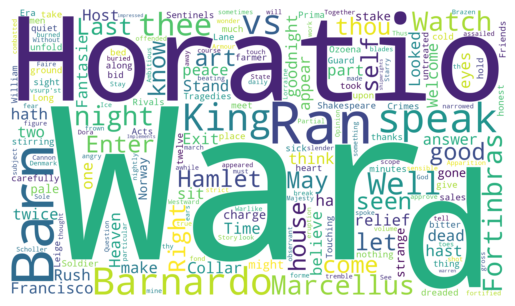

In [ ]:
# create a word cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(background_color="white", mask=plt.imread("/mask_oval.png")).generate(" ".join(corrected_words))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


## 12.7 (Textatistic: Readability of News Articles)
Using the techniques in the first exercise, download from several news sites current news articles on the same topic. Perform readability assessments on them to determine which sites are the most readable. For each article, calculate the average number of words per sentence, the average number of characters per word and the average number of syllables per word.

In [ ]:
%pip install textatistic

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for textatistic: filename=textatistic-0.0.1-py3-none-any.whl size=29047 sha256=e68672b0e6fe8e5d67428f9d4606548a0bbb1f8e1387ca2ad5b340b8cef4d65f
  Stored in directory: /root/.cache/pip/wheels/47/7b/d3/43882a340584b3c4b534e75ed4e7d08775c92d642890033ebb
  Created wheel for pyhyphen: filename=PyHyphen-4.0.4-cp37-abi3-linux_x86_64.whl size=66148 sha256=afe8a663f1a00abef082b3d6e157d1a9fe9c3ef948589d174e1b7929d6ee967e
  Stored in directory: /root/.cache/pip/wheels/1e/86/5f/638775dbcd75a522b2e416c918a10005d119067a49d75f144d
Successfully built textatistic pyhyphen


In [ ]:
from textatistic import Textatistic
# from bs4 import BeautifulSoup
# import requests

In [ ]:
# import re

def clean_web_text(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html5lib')

    # remove non-content elements
    for extra in soup(["script", "style", "noscript", "header", "footer", "nav"]):
        extra.extract()

    # get text with a space separator to prevent words from sticking together
    raw_text = soup.get_text(separator=' ')

    # use regex to keep words and sentence-ending punctuation (. ! ?)
    # filter out any single 'word' tokens longer than 100 chars
    tokens = []
    for token in raw_text.split():
        if len(token) <= 100:
            tokens.append(token)

    cleaned_text = ' '.join(tokens)
    return cleaned_text

# process the articles
cnn_clean = clean_web_text('https://www.cnn.com/politics/live-news/election-texas-north-carolina-primary-03-03-26')
fox_clean = clean_web_text('https://www.foxnews.com/live-news/primary-election-03-03-26')
ap_clean = clean_web_text('https://apnews.com/live/election-primary-3-3-2026')

# assess
readability_cnn = Textatistic(cnn_clean)
readability_fox = Textatistic(fox_clean)
readability_ap = Textatistic(ap_clean)

print(f"CNN Word Count: {readability_cnn.word_count}, Sentences: {readability_cnn.sent_count}")
print(f"Fox Word Count: {readability_fox.word_count}, Sentences: {readability_fox.sent_count}")
print(f"AP Word Count: {readability_ap.word_count}, Sentences: {readability_ap.sent_count}")
print("Readability processing complete.")

CNN Word Count: 3953, Sentences: 235
Fox Word Count: 9378, Sentences: 504
AP Word Count: 6200, Sentences: 140
Readability processing complete.


In [ ]:
# get more readability scores
print(f"CNN: {readability_cnn.dict()}")
print(f"Fox: {readability_fox.dict()}")
print(f"AP: {readability_ap.dict()}")

CNN: {'char_count': 19918, 'word_count': 3953, 'sent_count': 235, 'sybl_count': 5449, 'notdalechall_count': 1536, 'polysyblword_count': 330, 'flesch_score': 73.1448092641732, 'fleschkincaid_score': 7.235969514131471, 'gunningfog_score': 10.067746661571336, 'smog_score': 9.898777417752306, 'dalechall_score': 10.606286874929355}
Fox: {'char_count': 48428, 'word_count': 9378, 'sent_count': 504, 'sybl_count': 13406, 'notdalechall_count': 3526, 'polysyblword_count': 869, 'flesch_score': 67.0117058541267, 'fleschkincaid_score': 8.535073195625024, 'gunningfog_score': 11.149404381074248, 'smog_score': 10.630452183662179, 'dalechall_score': 10.496238768546446}
AP: {'char_count': 33116, 'word_count': 6200, 'sent_count': 140, 'sybl_count': 8715, 'notdalechall_count': 2868, 'polysyblword_count': 517, 'flesch_score': 42.967419354838725, 'fleschkincaid_score': 18.26804147465438, 'gunningfog_score': 21.049769585253458, 'smog_score': 14.107174899544091, 'dalechall_score': 13.137219815668203}


##12.8 (spaCy: Named Entity Recognition)
Using the techniques in the first exercise, download a current news article then use the spaCy library’s named entity recognition capabilities to display the named entities (people, places, organizations, etc.) in the article.

In [ ]:
import spacy
from spacy import displacy
from collections import Counter

ap_clean = clean_web_text('https://apnews.com/live/election-primary-3-3-2026')

nlp = spacy.load("en_core_web_sm")
doc = nlp(ap_clean)

for ent in doc.ents:
    print(ent.text, ent.label_)

March 3 DATE
Texas GPE
GOP ORG
Senate ORG
AP News Menu World ORG
Russia GPE
Español China Asia Pacific Latin America ORG
Iran GPE
US GPE
Iranian NORP
Iran GPE
the Middle East LOC
France GPE
the Mediterranean Newsletters The Morning Wire ORG
the day DATE
The Afternoon Wire LAW
the day DATE
All Newsletters U.S. SECTIONS Immigration Weather Education Transportation Abortion LGBTQ+ Notable Deaths ORG
US GPE
Iran GPE
Deadliest Catch' PERSON
Todd Meadows PERSON
Coast Guard ORG
Alexander PERSON
Newsletters The Morning Wire PERSON
the day DATE
All Newsletters AP QUIZZES Test Your News PERSON
I.Q. GPE
today DATE
Politics SECTIONS 2026 ORG
Congress Supreme Court ORG
AP ORG
Ground Game Early FAC
Trump ORG
MAGA ORG
Iran GPE
US GPE
Iranian NORP
Kuwait Tensions ORG
Iran GPE
Newsletters Ground PERSON
All Newsletters Sports SECTIONS ORG
2026 DATE
25 CARDINAL
NBA ORG
World Cup EVENT
less than $17 MONEY
Mexico Top-ranked GPE
Aryna Sabalenka PERSON
Frangulis Snooze PERSON
San Antonio's GPE
Harrison Barne

##12.9 (spaCy: Similarity Detection)
Using the techniques in the first exercise, download several news articles on the same topic and compare them for similarity.

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")
from pathlib import Path
similarity_ap_cnn = nlp(ap_clean).similarity(nlp(cnn_clean))
similarity_ap_fox = nlp(ap_clean).similarity(nlp(fox_clean))
similarity_cnn_fox = nlp(cnn_clean).similarity(nlp(fox_clean))

/tmp/ipykernel_2816/3370396264.py:4: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors, or use one of the larger models instead if available.
  similarity_ap_cnn = nlp(ap_clean).similarity(nlp(cnn_clean))
/tmp/ipykernel_2816/3370396264.py:5: UserWarning: [W007] The model you're using has no word vectors loaded, so the result of the Doc.similarity method will be based on the tagger, parser and NER, which may not give useful similarity judgements. This may happen if you're using one of the small models, e.g. `en_core_web_sm`, which don't ship with word vectors and only use context-sensitive tensors. You can always add your own word vectors,

In [ ]:
%precision 3
'%.3f'

print(f'AP to Fox: {similarity_ap_fox:.3f}')
print(f'AP to CNN: {similarity_ap_cnn:.3f}')
print(f'CNN to Fox: {similarity_cnn_fox:.3f}')

AP to Fox: 0.835
AP to CNN: 0.846
CNN to Fox: 0.988


##12.10 (spaCy: Shakespeare Similarity Detection)
Using the spaCy techniques you learned in this chapter, download a Shakespeare comedy from Project Gutenberg and compare it for similarity with Romeo and Juliet.

In [ ]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 26.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# import romeo and juliet from Project Gutenberg

request_rj = requests.get('https://www.gutenberg.org/cache/epub/1513/pg1513.txt')
request_ts = requests.get('https://www.gutenberg.org/cache/epub/1508/pg1508.txt')

stop_words = set(stopwords.words("english"))

#remove stop words
def remove_stop_words(text):
  tokens = word_tokenize(text)
  filtered_tokens = [token for token in tokens if token.lower() not in stop_words]
  return ' '.join(filtered_tokens)

# start with the story
raw_text_rj = remove_stop_words(request_rj.text)
raw_text_ts = remove_stop_words(request_ts.text)

# compare the texts for similarity using spaCy
nlp = spacy.load("en_core_web_md")
similarity_rj_ts = nlp(raw_text_rj).similarity(nlp(raw_text_ts))
print(f'Romeo and Juliet to The Taming of the Shrew: {similarity_rj_ts:.3f}')


Romeo and Juliet to The Taming of the Shrew: 0.995


##12.11 (textblob.utils Utility Functions)
TextBlob’s textblob.utils module offers several utility functions for cleaning up text, including strip_punc and lowerstrip. You call strip_punc with a string and the keyword argument all=True to remove punctuation from the string. You call lowerstrip with a string and the keyword argument all=True to get a string in all lowercase letters with whitespace and punctuation removed. Experiment with each function on Romeo and Juliet.

In [ ]:
from textblob.utils import strip_punc, lowerstrip

raw_text_rj = request_rj.text

raw_text_rj_lowerstrip = lowerstrip(raw_text_rj, all=True)
raw_text_rj_strip_punc = strip_punc(raw_text_rj, all=True)

# print 1000 words from the middle
print('Lowerstrip results:')
print(raw_text_rj_lowerstrip[1000:2000])
print()
print('Strip Punctuation results:')
print(raw_text_rj_strip_punc[1000:2000])

Lowerstrip results:
i
scene i a public place
scene ii a street
scene iii room in capulet’s house
scene iv a street
scene v a hall in capulet’s house

act ii
chorus
scene i an open place adjoining capulet’s garden
scene ii capulet’s garden
scene iii friar lawrence’s cell
scene iv a street
scene v capulet’s garden
scene vi friar lawrence’s cell

act iii
scene i a public place
scene ii a room in capulet’s house
scene iii friar lawrence’s cell
scene iv a room in capulet’s house
scene v an open gallery to juliet’s chamber overlooking the garden

act iv
scene i friar lawrence’s cell
scene ii hall in capulet’s house
scene iii juliet’s chamber
scene iv hall in capulet’s house
scene v juliet’s chamber juliet on the bed

act v
scene i mantua a street
scene ii friar lawrence’s cell
scene iii a churchyard in it a monument belonging to the capulets




 dramatis personæ

escalus prince of verona
mercutio kinsman to the prince and friend to romeo
paris a young nobleman kinsman 

Strip Punctuation re

##12.12 (Research: Funny Newspaper Headlines)
To understand how tricky it is to work with natural language and its inherent ambiguity issues, research “funny newspaper headlines.” List the challenges you find.

This encompasses the true challenge of NLP.
Funny, like many other words, has many different *denotations*, which can be used in different circumstances, but it also has many *connotations*, which may not be captured in a dictionary.  

For example, the denotations (literal definitions) of "Funny" are:

* providing fun; causing amusement or laughter; amusing; comical.
> a funny remark;
> a funny person.

Synonyms:
humorous, facetious, witty, droll, ridiculous, farcical, comic, diverting
attempting to amuse;

*Did you really mean that or were you just being **funny**?*

* warranting suspicion; deceitful; underhanded.
> *We thought there was something **funny** about those extra charges.*

* Informal. insolent; impertinent.
> *Don't get **funny** with me, young man!*

* curious; strange; peculiar; odd.
> *Her speech has a **funny** twang.*

As you can see, there are 18 varying synonyms of *funny* in the dictionary! So, it is no wonder that an NLP program would struggle with connotations and inferring meaning, without a significant amount of context. Additionally, even if it were able to do all of that (and probably can with the right training), is it possible for it to detect sarcasm?

##12.13 (Try the Demos: Named Entity Recognition)
Search online for the Stanford Named Entity Tagger and the Cognitive Computation Group’s Named Entity Recognition Demo. Run each with a corpus of your choice. Compare the results of both demos.

In [ ]:
from nltk.tag import StanfordNERTagger
from nltk.tokenize import word_tokenize

request = requests.get('https://apnews.com/article/ann-godoff-dies-publisher-penguin-random-house-5107624b9be58ab5479988b3e5eab4d2')
    # remove non-content elements
soup = BeautifulSoup(request.content, 'html5lib')
for extra in soup(["script", "style", "noscript", "header", "footer", "nav"]):
  extra.extract()

raw_text = soup.get_text(separator=' ')
# run NER tagger on request
st = StanfordNERTagger('/stanford-ner-2020-11-17/stanford-ner-4.2.0', raw_text, encoding='utf-8')

LookupError: Could not find stanford-ner.jar jar file at 
    
        

 

    
     

     

     

     
     

    
     
    
     
     
     
    
     
    


     

     



     

     

     

     

     

     

     

     

     

     

     

     

     

     

    
     
    
    
     
    
    
    
     
    
    
     

     
    
 

    
    
     
    

     


     

     

     


     


     


     

 
     
     

    
     

    
         
         

         
         
     
 
 
 
 
 
 
 
 
 

     Penguin Press founder Ann Godoff, a visionary in publishing, dies | AP News 
         
         
         
         
         
    
         
    

     
     

     
    
         
    

    
     
     
     
     
     
 
 
 
 
 
 
 
 
 
 
 
 

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 

 
 

 
     
     

     
         

     


    
    
         
         
     
         
     

     
         
     

     
         
     

     
         
     

##12.14 (Try the Demo: TextRazor)
TextRazor is one of many paid commercial NLP products that offer a free tier. Search online for TextRazor Live Demo. Paste in a corpus of your choice and click Analyze to analyze the corpus for categories and topics, highlighting key sentences and words within them. Click the links below each piece of analyzed text for more detailed analyses. Click the Advanced Options link to the right of Analyze and Clear for many additional features, including the ability to analyze text in different languages.

##12.15 (Project: Readability Scores with Textatistic)
Try Textatistic with famous authors’ books from Project Gutenberg.

In [ ]:
gutenberg.fileids()

# get textastisic readability scores for each book in gutenberg.fileids()
for book in gutenberg.fileids():
  text = gutenberg.raw(book)
  readability = Textatistic(text)
  print(f'{book}: {readability.dict()}')

austen-emma.txt: {'char_count': 722627, 'word_count': 160995, 'sent_count': 10559, 'sybl_count': 205438, 'notdalechall_count': 23494, 'polysyblword_count': 8767, 'flesch_score': 83.4051062236996, 'fleschkincaid_score': 5.41381537976374, 'gunningfog_score': 8.277077291395818, 'smog_score': 8.334559167219101, 'dalechall_score': 6.696994917590643}
austen-persuasion.txt: {'char_count': 380023, 'word_count': 83659, 'sent_count': 3667, 'sybl_count': 108714, 'notdalechall_count': 12695, 'polysyblword_count': 5306, 'flesch_score': 73.741953130254, 'fleschkincaid_score': 8.641443810981828, 'gunningfog_score': 11.662572301696404, 'smog_score': 10.000941021423962, 'dalechall_score': 7.164159939603207}
austen-sense.txt: {'char_count': 549517, 'word_count': 119957, 'sent_count': 5926, 'sybl_count': 157929, 'notdalechall_count': 19308, 'polysyblword_count': 8125, 'flesch_score': 74.90901580524309, 'fleschkincaid_score': 7.839823178918898, 'gunningfog_score': 10.806300454873032, 'smog_score': 9.81832

##12.16 (Project: Who Authored the Works of Shakespeare)
Using the spaCy similarity detection code introduced in this chapter, compare Shakespeare’s Macbeth to one major work from each of several other authors who might have written Shakespeare’s works (see [Wikipedia](https://en.wikipedia.org/wiki/Shakespeare_authorship_question)). Locate works on Project Gutenberg from [a few authors listed at this link](https://en.wikipedia.org/wiki/List_of_Shakespeare_authorship_candidates), then use spaCy to compare their works’ similarity to Macbeth. Which of the authors’ works are most similar to Macbeth?

In [ ]:
from nltk.corpus import gutenberg
from bs4 import BeautifulSoup
import requests
from nltk.tokenize import word_tokenize
import spacy

shakespeare_raw = gutenberg.raw('shakespeare-macbeth.txt')
bacon_response = requests.get('https://www.gutenberg.org/cache/epub/5500/pg5500.txt')
marlowe_response = requests.get('https://www.gutenberg.org/cache/epub/779/pg779.txt')

stop_words = set(stopwords.words("english"))

def process_text_from_soup(soup_obj):
    '''pass a BeautifulSoup object and extract text, remove unwanted tags'''
    for extra in soup_obj(["script", "style", "noscript", "header", "footer", "nav"]):
        extra.extract()
    text = soup_obj.get_text(separator=' ')
    return text

def remove_stop_words(text):
  tokens = word_tokenize(text)
  filtered_tokens = [token for token in tokens if token.lower() not in stop_words]
  return ' '.join(filtered_tokens)

shakespeare_soup = BeautifulSoup(shakespeare_raw, 'html5lib')
bacon_soup = BeautifulSoup(bacon_response.text, 'html5lib')
marlowe_soup = BeautifulSoup(marlowe_response.text, 'html5lib')

# apply process_text_from_soup to get the clean text strings
shakespeare_processed_text = process_text_from_soup(shakespeare_soup)
bacon_processed_text = process_text_from_soup(bacon_soup)
marlowe_processed_text = process_text_from_soup(marlowe_soup)

# remove stop words from the processed text strings
shakespeare_text = remove_stop_words(shakespeare_processed_text)
bacon_text = remove_stop_words(bacon_processed_text)
marlowe_text = remove_stop_words(marlowe_processed_text)

nlp = spacy.load("en_core_web_md")
similarity_shakespeare_bacon = nlp(shakespeare_text).similarity(nlp(bacon_text))
similarity_shakespeare_marlowe = nlp(shakespeare_text).similarity(nlp(marlowe_text))
print(f'Shakespeare to Bacon: {similarity_shakespeare_bacon:.3f}')
print(f'Shakespeare to Marlowe: {similarity_shakespeare_marlowe:.3f}')


Shakespeare to Bacon: 0.958
Shakespeare to Marlowe: 0.976


In [ ]:
similarity_bacon_marlowe = nlp(bacon_text).similarity(nlp(marlowe_text))
print(f'Bacon to Marlowe: {similarity_bacon_marlowe:.3f}')

Bacon to Marlowe: 0.973


##12.17 (Project: Similarity Detection)
One way to measure similarity between two documents is to compare frequency counts of the parts of speech used in each. Build dictionaries of the parts of speech frequencies for two Project Gutenberg books from the same author and two from different authors and compare the results.

In [ ]:
emma_raw = gutenberg.raw('austen-emma.txt')
persuasion_raw = gutenberg.raw('austen-persuasion.txt')
macbeth_raw = gutenberg.raw('shakespeare-macbeth.txt')
mobydick_raw = gutenberg.raw('melville-moby_dick.txt')

nlp = spacy.load("en_core_web_md")

from collections import Counter

def get_pos_frequencies(text, nlp_model):
    doc = nlp_model(text)
    pos_counts = Counter()
    for token in doc:
        if token.pos_ != 'SPACE':
            pos_counts[token.pos_] += 1

    total_tokens = sum(pos_counts.values())
    pos_frequencies = {pos: count / total_tokens for pos, count in pos_counts.items()}
    return pos_frequencies

nlp.max_length = max(len(emma_raw), len(persuasion_raw), len(macbeth_raw), len(mobydick_raw)) + 100

emma_pos_freq = get_pos_frequencies(emma_raw, nlp)
persuasion_pos_freq = get_pos_frequencies(persuasion_raw, nlp)
macbeth_pos_freq = get_pos_frequencies(macbeth_raw, nlp)
mobydick_pos_freq = get_pos_frequencies(mobydick_raw, nlp)

print('--- Jane Austen - Emma POS Frequencies ---')
for pos, freq in sorted(emma_pos_freq.items()):
    print(f'{pos}: {freq:.4f}')
print('\n--- Jane Austen - Persuasion POS Frequencies ---')
for pos, freq in sorted(persuasion_pos_freq.items()):
    print(f'{pos}: {freq:.4f}')
print('\n--- William Shakespeare - Macbeth POS Frequencies ---')
for pos, freq in sorted(macbeth_pos_freq.items()):
    print(f'{pos}: {freq:.4f}')
print('\n--- Herman Melville - Moby Dick POS Frequencies ---')
for pos, freq in sorted(mobydick_pos_freq.items()):
    print(f'{pos}: {freq:.4f}')

--- Jane Austen - Emma POS Frequencies ---
ADJ: 0.0605
ADP: 0.0854
ADV: 0.0628
AUX: 0.0817
CCONJ: 0.0361
DET: 0.0632
INTJ: 0.0031
NOUN: 0.1138
NUM: 0.0049
PART: 0.0345
PRON: 0.1258
PROPN: 0.0494
PUNCT: 0.1478
SCONJ: 0.0238
SYM: 0.0000
VERB: 0.1070
X: 0.0002

--- Jane Austen - Persuasion POS Frequencies ---
ADJ: 0.0601
ADP: 0.0954
ADV: 0.0589
AUX: 0.0768
CCONJ: 0.0387
DET: 0.0678
INTJ: 0.0021
NOUN: 0.1193
NUM: 0.0057
PART: 0.0335
PRON: 0.1168
PROPN: 0.0515
PUNCT: 0.1442
SCONJ: 0.0229
SYM: 0.0000
VERB: 0.1062
X: 0.0000

--- William Shakespeare - Macbeth POS Frequencies ---
ADJ: 0.0447
ADP: 0.0685
ADV: 0.0331
AUX: 0.0454
CCONJ: 0.0344
DET: 0.0541
INTJ: 0.0042
NOUN: 0.1134
NUM: 0.0063
PART: 0.0211
PRON: 0.1173
PROPN: 0.1562
PUNCT: 0.1869
SCONJ: 0.0164
SYM: 0.0000
VERB: 0.0961
X: 0.0018

--- Herman Melville - Moby Dick POS Frequencies ---
ADJ: 0.0702
ADP: 0.1042
ADV: 0.0553
AUX: 0.0430
CCONJ: 0.0357
DET: 0.0967
INTJ: 0.0023
NOUN: 0.1647
NUM: 0.0085
PART: 0.0200
PRON: 0.0824
PROPN: 0.0369
PU

##12.18 (Project: Text Visualization Browser)
Use [http://textvis.lnu.se/](http://textvis.lnu.se/) to view hundreds of text visualizations. You can filter the visualizations by categories like the analytic tasks they perform, the kinds of visualizations, the kinds of data sources they use and more. Each visualization’s summary provides a link to where you can learn more about it.

Reviewed

##12.19 (Project: Stanford CoreNLP)
Search online for “Stanford CoreNLP Python” to find Stanford’s list of Python modules for using CoreNLP, then experiment with its features to perform tasks you learned in this chapter.

In [ ]:
%pip install stanfordnlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 kB 7.5 MB/s eta 0:00:00


In [ ]:
import stanfordnlp
stanfordnlp.download('en')   # This downloads the English models for the neural pipeline


Using the default treebank "en_ewt" for language "en".
Would you like to download the models for: en_ewt now? (Y/n)


Default download directory: /root/stanfordnlp_resources
Hit enter to continue or type an alternate directory.


Download location: /root/stanfordnlp_resources/en_ewt_models.zip


100%|██████████| 235M/235M [00:42<00:00, 5.58MB/s]



Download complete.  Models saved to: /root/stanfordnlp_resources/en_ewt_models.zip
Extracting models file for: en_ewt
Cleaning up...Done.


##12.20 (Project: spaCy and spacy-readability)
We used Textatistic for readability assessment in this chapter. There are many other readability libraries, such as readability-score, textstat, readability, pylinguistics and spacy-readability, which works in conjunction with spaCy. Investigate the spacy-readability module, then use it to evaluate the readability of King Lear (from Project Gutenberg).

In [ ]:
!apt-get install spacy-readability

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package spacy-readability


In [ ]:
import requests
import spacy
from spacy_readability import Readability

nlp = spacy.load('en')
nlp.add_pipe(Readability())

doc = nlp(gutenberg.raw('shakespeare-kinglear.txt'))

# lear_raw = requests.get('https://www.gutenberg.org/cache/epub/1532/pg1532.txt')
doc._.flesch_kincaid_grade_level
doc._.flesch_kincaid_reading_ease
doc._.dale_chall


ModuleNotFoundError: No module named 'spacy_readability'

## 12.21 (Project: Worldwide Peace)
As you know, TextBlob language translation works by connecting to Google Translate. Determine the range of languages Google Translate recognizes. Write a script that translates the English word “Peace” into each of the supported languages. Display the translations in the same size text in a circular word cloud using the mask_circle.png file provided in the  examples folder.

## 12.22 (Project: Self Tutor for Learning a New Language)
With today’s natural language tools, including inter-language translation, speech-to-text and text-to-speech in various languages, you can build a self-tutor that will help you learn new languages. Find Python speech-to-text and text-to-speech libraries that can handle various languages. Write a script that allows you to indicate the language you wish to learn (use only the languages supported by Google Translate through TextBlob). The script should then allow you to say something in English, transcribe your speech to text, translate it to the selected language and use text-to-speech to speak the translated text back to you so you can hear it. Try your script with words, colors, numbers, sentences, people, places and things.

## 12.23 (Project: Accessing Wikipedia with Python)
Search online for Python modules that enable you to access content from Wikipedia and similar sites. Write scripts to exercise the capabilities of those modules.

In [ ]:
# https://www.mediawiki.org/wiki/API:REST_API/Reference#Python

import requests
import json
from IPython.display import HTML
from IPython.display import Image

search_query = 'machine learning'
number_of_results = 5
endpoint = 'search/page'
base_url = 'https://en.wikipedia.org/w/rest.php/v1/'

# See https://www.mediawiki.org/wiki/API:REST_API#Client_identification
headers = {'User-Agent': 'MediaWiki REST API docs examples/0.1 (https://meta.wikimedia.org/wiki/User:APaskulin_(WMF))'}

url = base_url + endpoint
response = requests.get(url, headers=headers, params={'q': search_query, 'limit': number_of_results})
data = response.json()

for page in data['pages']:
  print(page['title'])
  print('https://en.wikipedia.org/wiki/' + page['key'])
  if page['description'] is not None:
    print(page['description'])
  print()
  display(HTML('<a href="https://en.wikipedia.org/wiki/' + page['key'] + '">' + page['title'] + '</a>'))
  display(HTML(page['excerpt']))
  try:
    thumbnail_url = 'https:' + page['thumbnail']['url']
    display(Image(data=thumbnail_url, width=page['thumbnail']['width'], height=page['thumbnail']['height']))
  except Exception as e:
    print(e)

Machine learning
https://en.wikipedia.org/wiki/Machine_learning
Study of algorithms that improve automatically through experience



'NoneType' object is not subscriptable
Attention (machine learning)
https://en.wikipedia.org/wiki/Attention_(machine_learning)
Machine learning technique



HTTP Error 403: Forbidden
Neural network (machine learning)
https://en.wikipedia.org/wiki/Neural_network_(machine_learning)
Computational model used in machine learning, based on connected, hierarchical functions



HTTP Error 403: Forbidden
Quantum machine learning
https://en.wikipedia.org/wiki/Quantum_machine_learning
Interdisciplinary research area



HTTP Error 403: Forbidden
Explainable artificial intelligence
https://en.wikipedia.org/wiki/Explainable_artificial_intelligence
AI whose outputs can be understood by humans



'NoneType' object is not subscriptable


## 12.24 (Project: Document Summarization with Gensim)
Document summarization involves analyzing a document and extracting content to produce a summary. For example, with today’s massive flow of information, this could be useful to busy doctors studying the latest medical advances in order to provide the best care. A summary could help them decide whether a paper is worth reading. Investigate the  and  functions from the Gensim library’s  module, then use them to summarize text and extract the important words. You’ll need to install Gensim with
              
```python
conda install -c conda-forge genism
```                    
Assuming that  is a string representing a corpus, the following Gensim code summarizes the text and displays a list of keywords in the text:

```python
from gensim.summarization import summarize,keywords
print(summarize(text))
print(keywords(text))
```


              

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.1 MB/s eta 0:00:00


In [ ]:
from gensim import corpora, models, similarities, downloader
from gensim.summarization import summarize, keywords

ModuleNotFoundError: No module named 'gensim.summarization'

## 12.25 (Challenge Project: Six Degrees of Separation with Wikipedia Corpus)
You may have heard of “six degrees of separation” for finding connections between any two people on the planet. The idea is that as you look at a person’s connections to friends and family, then look at their friends’ and family’s connections, and so on, you’ll often find a connection between two people within the first six levels of connection.
                
              
Research “six degrees of separation Python” online. You’ll find many implementations. Execute some of them to see how they do. Next, investigate the Wikipedia APIs and Python modules for using them. Choose two famous people. Load the Wikipedia page for the first person, then use named entity recognition to locate any names in that person’s Wikipedia page. Then repeat this process for the Wikipedia pages of each name you find. Continue this process six levels deep to build a graph of people connected to the original person’s Wikipedia page. Along the way, check whether the other person’s name appears in the graph and print the chain of people. In the “Big Data: Hadoop, Spark, NoSQL and IoT” chapter, we’ll discuss the Neo4j graph database, which can be used to solve this problem.

## 12.26 (Project: Synonym Chain Leading to an Antonym)
As you follow synonym chains—that is, synonyms of synonyms of synonyms, etc.—to arbitrary levels, you’ll often encounter words that do not appear to be related to the original. Though rare, there actually are cases in which following a synonym chain eventually results in an antonym of the initial word. For several examples, see the paper “Websterian Synonym Chains”:

https://digitalcommons.butler.edu/cgi/viewcontent.cgi?article=3342&context=wordways

Choose a synonym chain in the paper above. Use the WordNet features introduced in this chapter to get the first word’s synonyms and antonyms. Next, for each of the words in the Sysnsets, get their synonyms, then the synonyms of those synonyms and so on. As you get the synonyms at each level, check whether any of them is one of the initial word’s antonyms. If so, display the synonym chain that led to the antonym.

## 12.27 (Project: Steganography)
Steganography hides information within other information. The term literally means “covered writing.” Research online “text steganography” and “natural language steganography.” Write scripts that use various steganography techniques to hide information in text and to extract that information.